# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


**Deskripsi Dataset: Kesehatan Tidur dan Gaya Hidup**

Dataset yang digunakan dalam proyek ini adalah **[Sleep Health and Lifestyle Dataset](https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset)**. Secara spesifik, kita akan menganalisis faktor-faktor yang memengaruhi kualitas tidur dan risiko gangguan tidur.

---

**Sumber dan Konteks:**

Data ini mencakup 374 baris dan 13 kolom, yang berisi informasi mengenai profil sintetis individu terkait kesehatan tidur, aktivitas fisik, dan tekanan darah. Dataset ini dirancang untuk membantu pemodelan prediktif dalam mengidentifikasi hubungan antara gaya hidup (seperti pekerjaan dan tingkat stres) dengan kondisi kesehatan tidur seseorang.

---

**Variabel Target dan Klasifikasi**

Variabel target yang akan kita prediksi adalah **`Sleep Disorder`**. Kolom ini memiliki tiga kategori utama:

* **None**: Responden tidak memiliki gangguan tidur.
* **Insomnia**: Responden memiliki kesulitan tidur atau sering terjaga.
* **Sleep Apnea**: Responden mengalami gangguan pernapasan saat tidur.

---

**Deskripsi Fitur**

| Variabel | Deskripsi | Nilai |
| --- | --- | --- |
| **Sleep Disorder** | **Fitur Target** (Jenis gangguan tidur) | None, Insomnia, Sleep Apnea |
| **Person ID** | Identitas unik per individu|Nilai numerik|
| **Gender** | Jenis kelamin responden | Male, Female |
| **Age** | Usia responden dalam satuan tahun | Nilai numerik |
| **Occupation** | Profesi atau pekerjaan utama | Nurse, Doctor, Engineer, Lawyer, dll. |
| **Sleep Duration** | Jumlah jam tidur per hari | Nilai numerik (Jam) |
| **Quality of Sleep** | Rating subjektif kualitas tidur | Skala 1–10 |
| **Physical Activity Level** | Menit aktivitas fisik per hari | Nilai numerik (Menit) |
| **Stress Level** | Rating subjektif tingkat stres harian | Skala 1–10 |
| **BMI Category** | Kategori indeks massa tubuh | Normal, Overweight, Obese |
| **Blood Pressure** | Tekanan darah (Sistolik/Diastolik) | String (Contoh: 126/83) |
| **Heart Rate** | Denyut jantung istirahat (Resting HR) | Nilai numerik (bpm) |
| **Daily Steps** | Jumlah langkah kaki harian | Nilai numerik |

---

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Manipulasi Data dan Operasi Numerik
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # Supaya output lebih bersih

# Visualisasi Data
import seaborn as sns
import matplotlib.pyplot as plt

# Set style untuk visualisasi yang lebih baik
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Utilities
import kagglehub               # Interaksi dengan Kaggle API
import os                      # Interaksi dengan sistem operasi

# Random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

print("✅ Semua library berhasil diimport!")
print(f"📌 Random Seed: {RANDOM_SEED}")

✅ Semua library berhasil diimport!
📌 Random Seed: 42


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [18]:
# Baca data
df = pd.read_csv("../data_raw\Sleep_health_and_lifestyle_dataset_raw.csv")

# Tampilkan hasil
print("Berhasil membaca file: Sleep_health_and_lifestyle_dataset_raw.csv")
df.head()

Berhasil membaca file: Sleep_health_and_lifestyle_dataset_raw.csv


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

## **Dataset Structure**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


## **Missing Values Analysis**

In [6]:
df.isna().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

## **Duplicate Analysis**

In [7]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


## **Univariate Analysis**

### Target Variable: Sleep Disorder

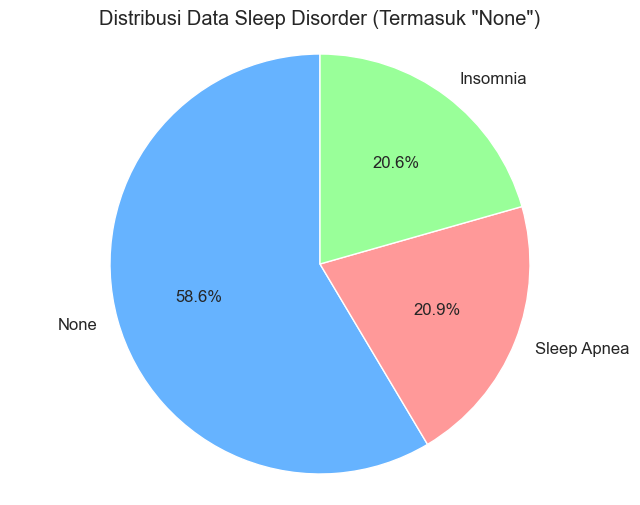

In [8]:
# Buat series sementara dengan 'None' untuk nilai NaN pada kolom 'Sleep Disorder'
sleep_disorder_temp = df['Sleep Disorder'].fillna('None')
sleep_disorder_counts = sleep_disorder_temp.value_counts()

# Buat labels
labels = sleep_disorder_counts.index.tolist()

# Buat pie chart
plt.figure(figsize=(8, 6))
# Gunakan palet warna yang sesuai dengan jumlah kategori
colors = ['#66b3ff', '#ff9999', '#99ff99'] # Contoh warna untuk maksimal 3 kategori
plt.pie(sleep_disorder_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors[:len(labels)])
plt.title('Distribusi Data Sleep Disorder (Termasuk "None")')
plt.axis('equal')
plt.show()

### Numerical Features

#### *Statistical Summary*

In [ ]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


#### *Distribution*

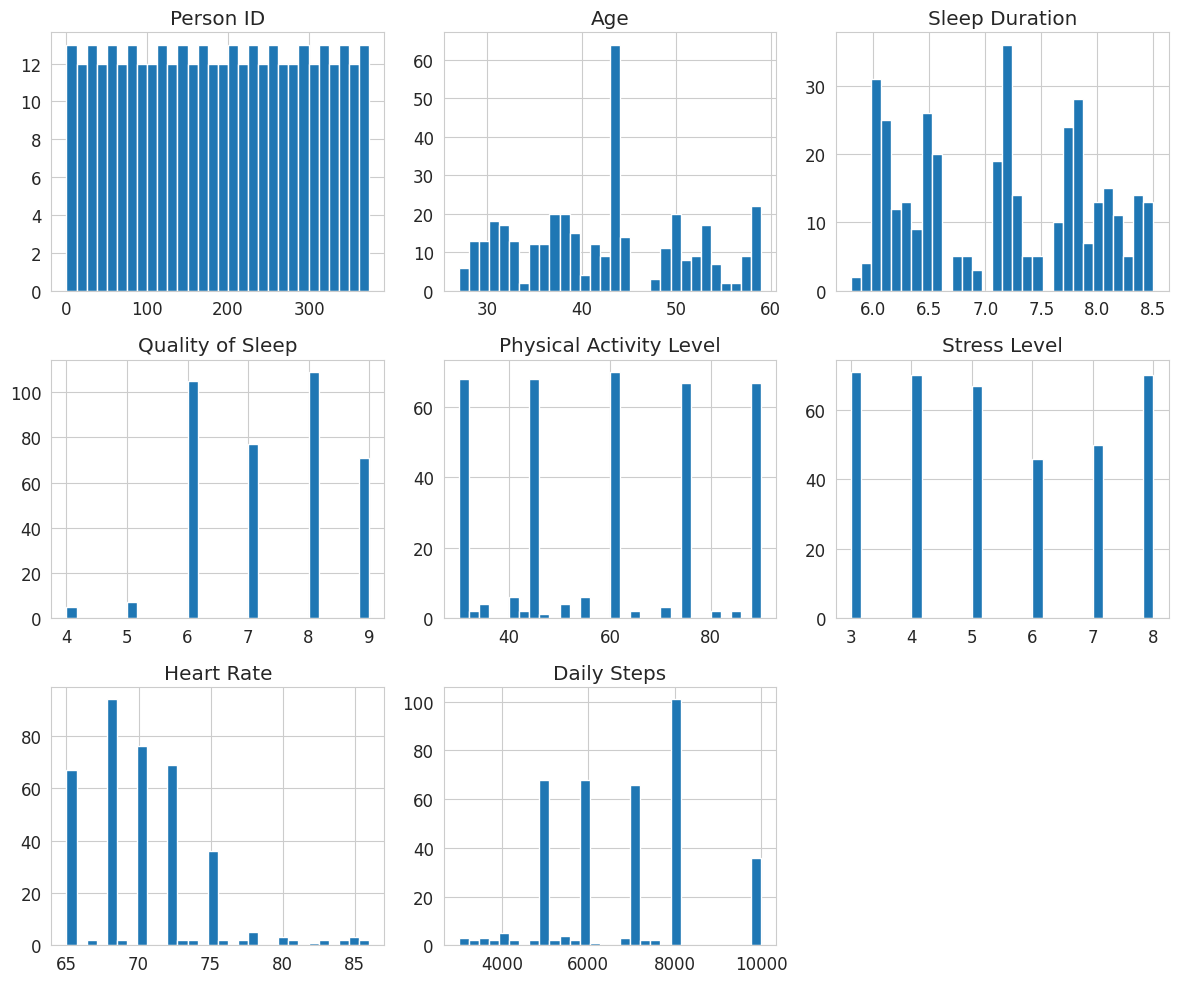

In [ ]:
df.hist(figsize=(12, 10), bins=30)
plt.tight_layout()

#### *Outlier Detection*

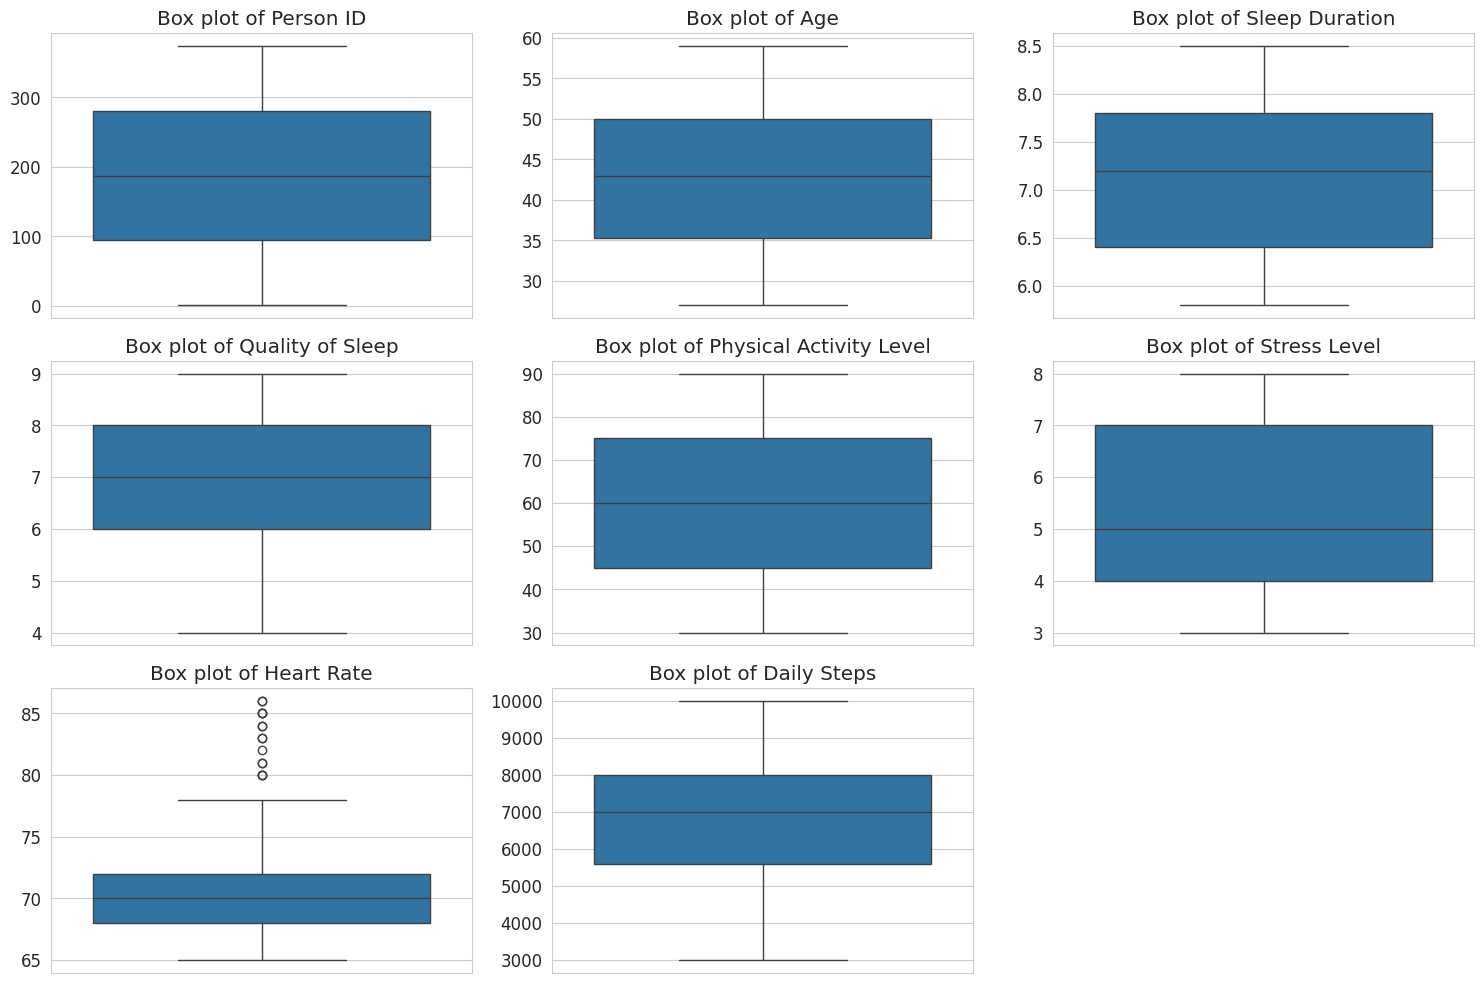

In [ ]:
numerical_features = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1) # Menyesuaikan layout subplot
    sns.boxplot(y=df[feature])
    plt.title(f'Box plot of {feature}')
    plt.ylabel('') # Hapus label y agar lebih rapi

plt.tight_layout()
plt.show()

### Categorical Features

#### *Cardinality (unique value count)*

In [ ]:
df.describe(include="object")

,Gender,Occupation,BMI Category,Blood Pressure,Sleep Disorder
count,374,374,374,374,155
unique,2,11,4,25,2
top,Male,Nurse,Normal,130/85,Sleep Apnea
freq,189,73,195,99,78


####  *Value counts & percentages*

In [ ]:
def value_counts_with_percentage(df, col):
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    return pd.DataFrame({'Count': counts, 'Percentage': percentages.round(2)})

# Identifikasi fitur kategorikal
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Sleep Disorder') # Kolom target sudah divisualisasikan

# Untuk semua fitur kategorikal
for col in categorical_cols:
    print(f"\nFitur: {col}")
    display(value_counts_with_percentage(df, col))


Fitur: Gender


,Count,Percentage
Gender,,
Male,189,50.53
Female,185,49.47



Fitur: Occupation


,Count,Percentage
Occupation,,
Nurse,73,19.52
Doctor,71,18.98
Engineer,63,16.84
Lawyer,47,12.57
Teacher,40,10.70
Accountant,37,9.89
Salesperson,32,8.56
Scientist,4,1.07
Software Engineer,4,1.07



Fitur: BMI Category


,Count,Percentage
BMI Category,,
Normal,195,52.14
Overweight,148,39.57
Normal Weight,21,5.61
Obese,10,2.67



Fitur: Blood Pressure


,Count,Percentage
Blood Pressure,,
130/85,99,26.47
140/95,65,17.38
125/80,65,17.38
120/80,45,12.03
115/75,32,8.56
135/90,27,7.22
140/90,4,1.07
125/82,4,1.07
128/85,3,0.80


#### *Visualization (bar charts)*

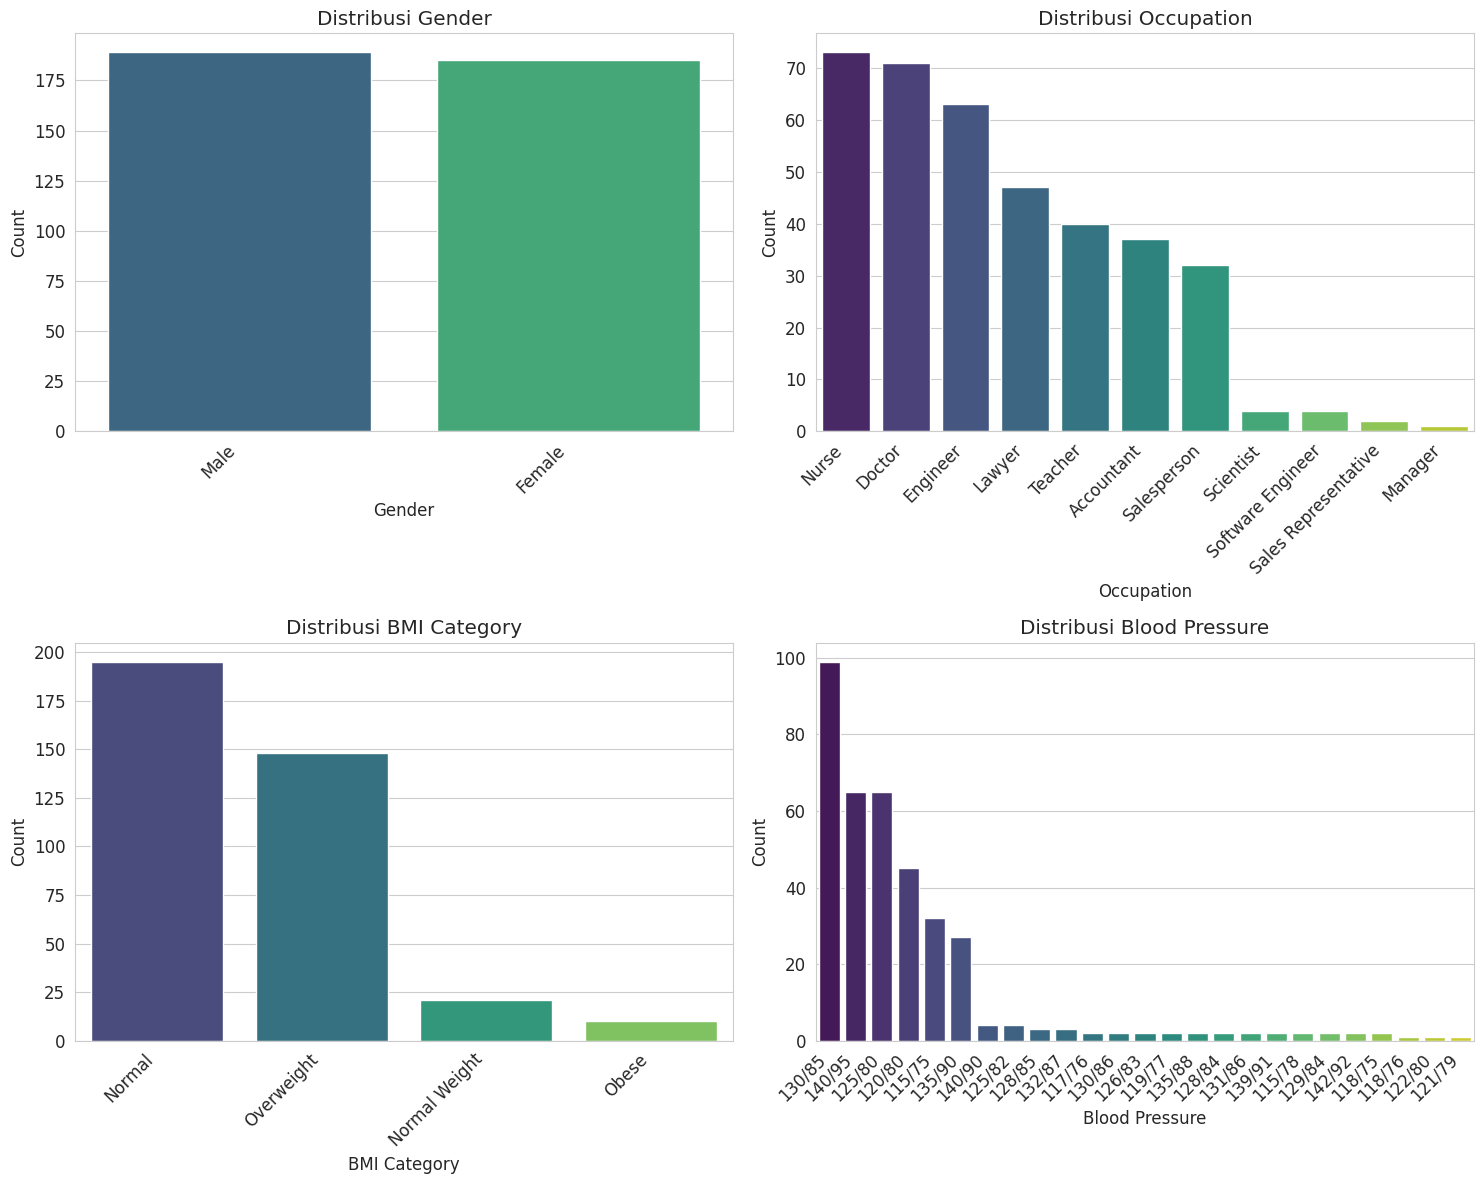

In [ ]:
plt.figure(figsize=(15, 12))
for i, feature in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1) # Menyesuaikan layout subplot
    sns.countplot(data=df, x=feature, palette='viridis', order=df[feature].value_counts().index)
    plt.title(f'Distribusi {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotasi label x untuk keterbacaan

plt.tight_layout()
plt.show()

#### *Outlier Detection*

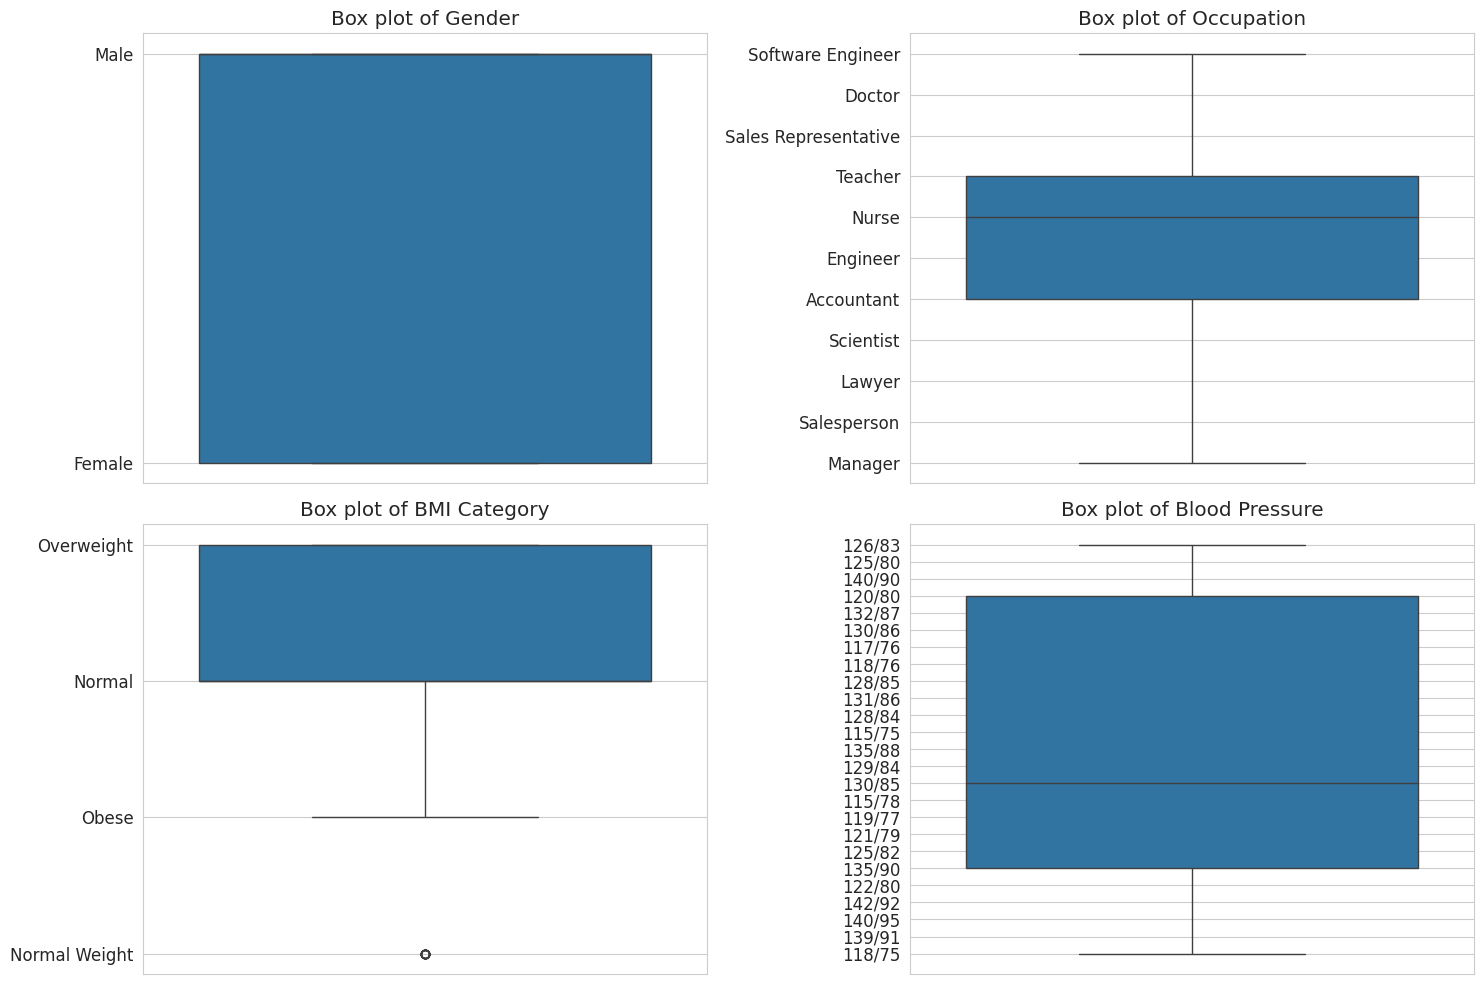

In [ ]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1) # Menyesuaikan layout subplot
    sns.boxplot(y=df[feature])
    plt.title(f'Box plot of {feature}')
    plt.ylabel('') # Hapus label y agar lebih rapi

plt.tight_layout()
plt.show()

## **Bivariate Analysis**

### Numerical Features

Bivariate Analysis: Numerical Features vs. Sleep Disorder


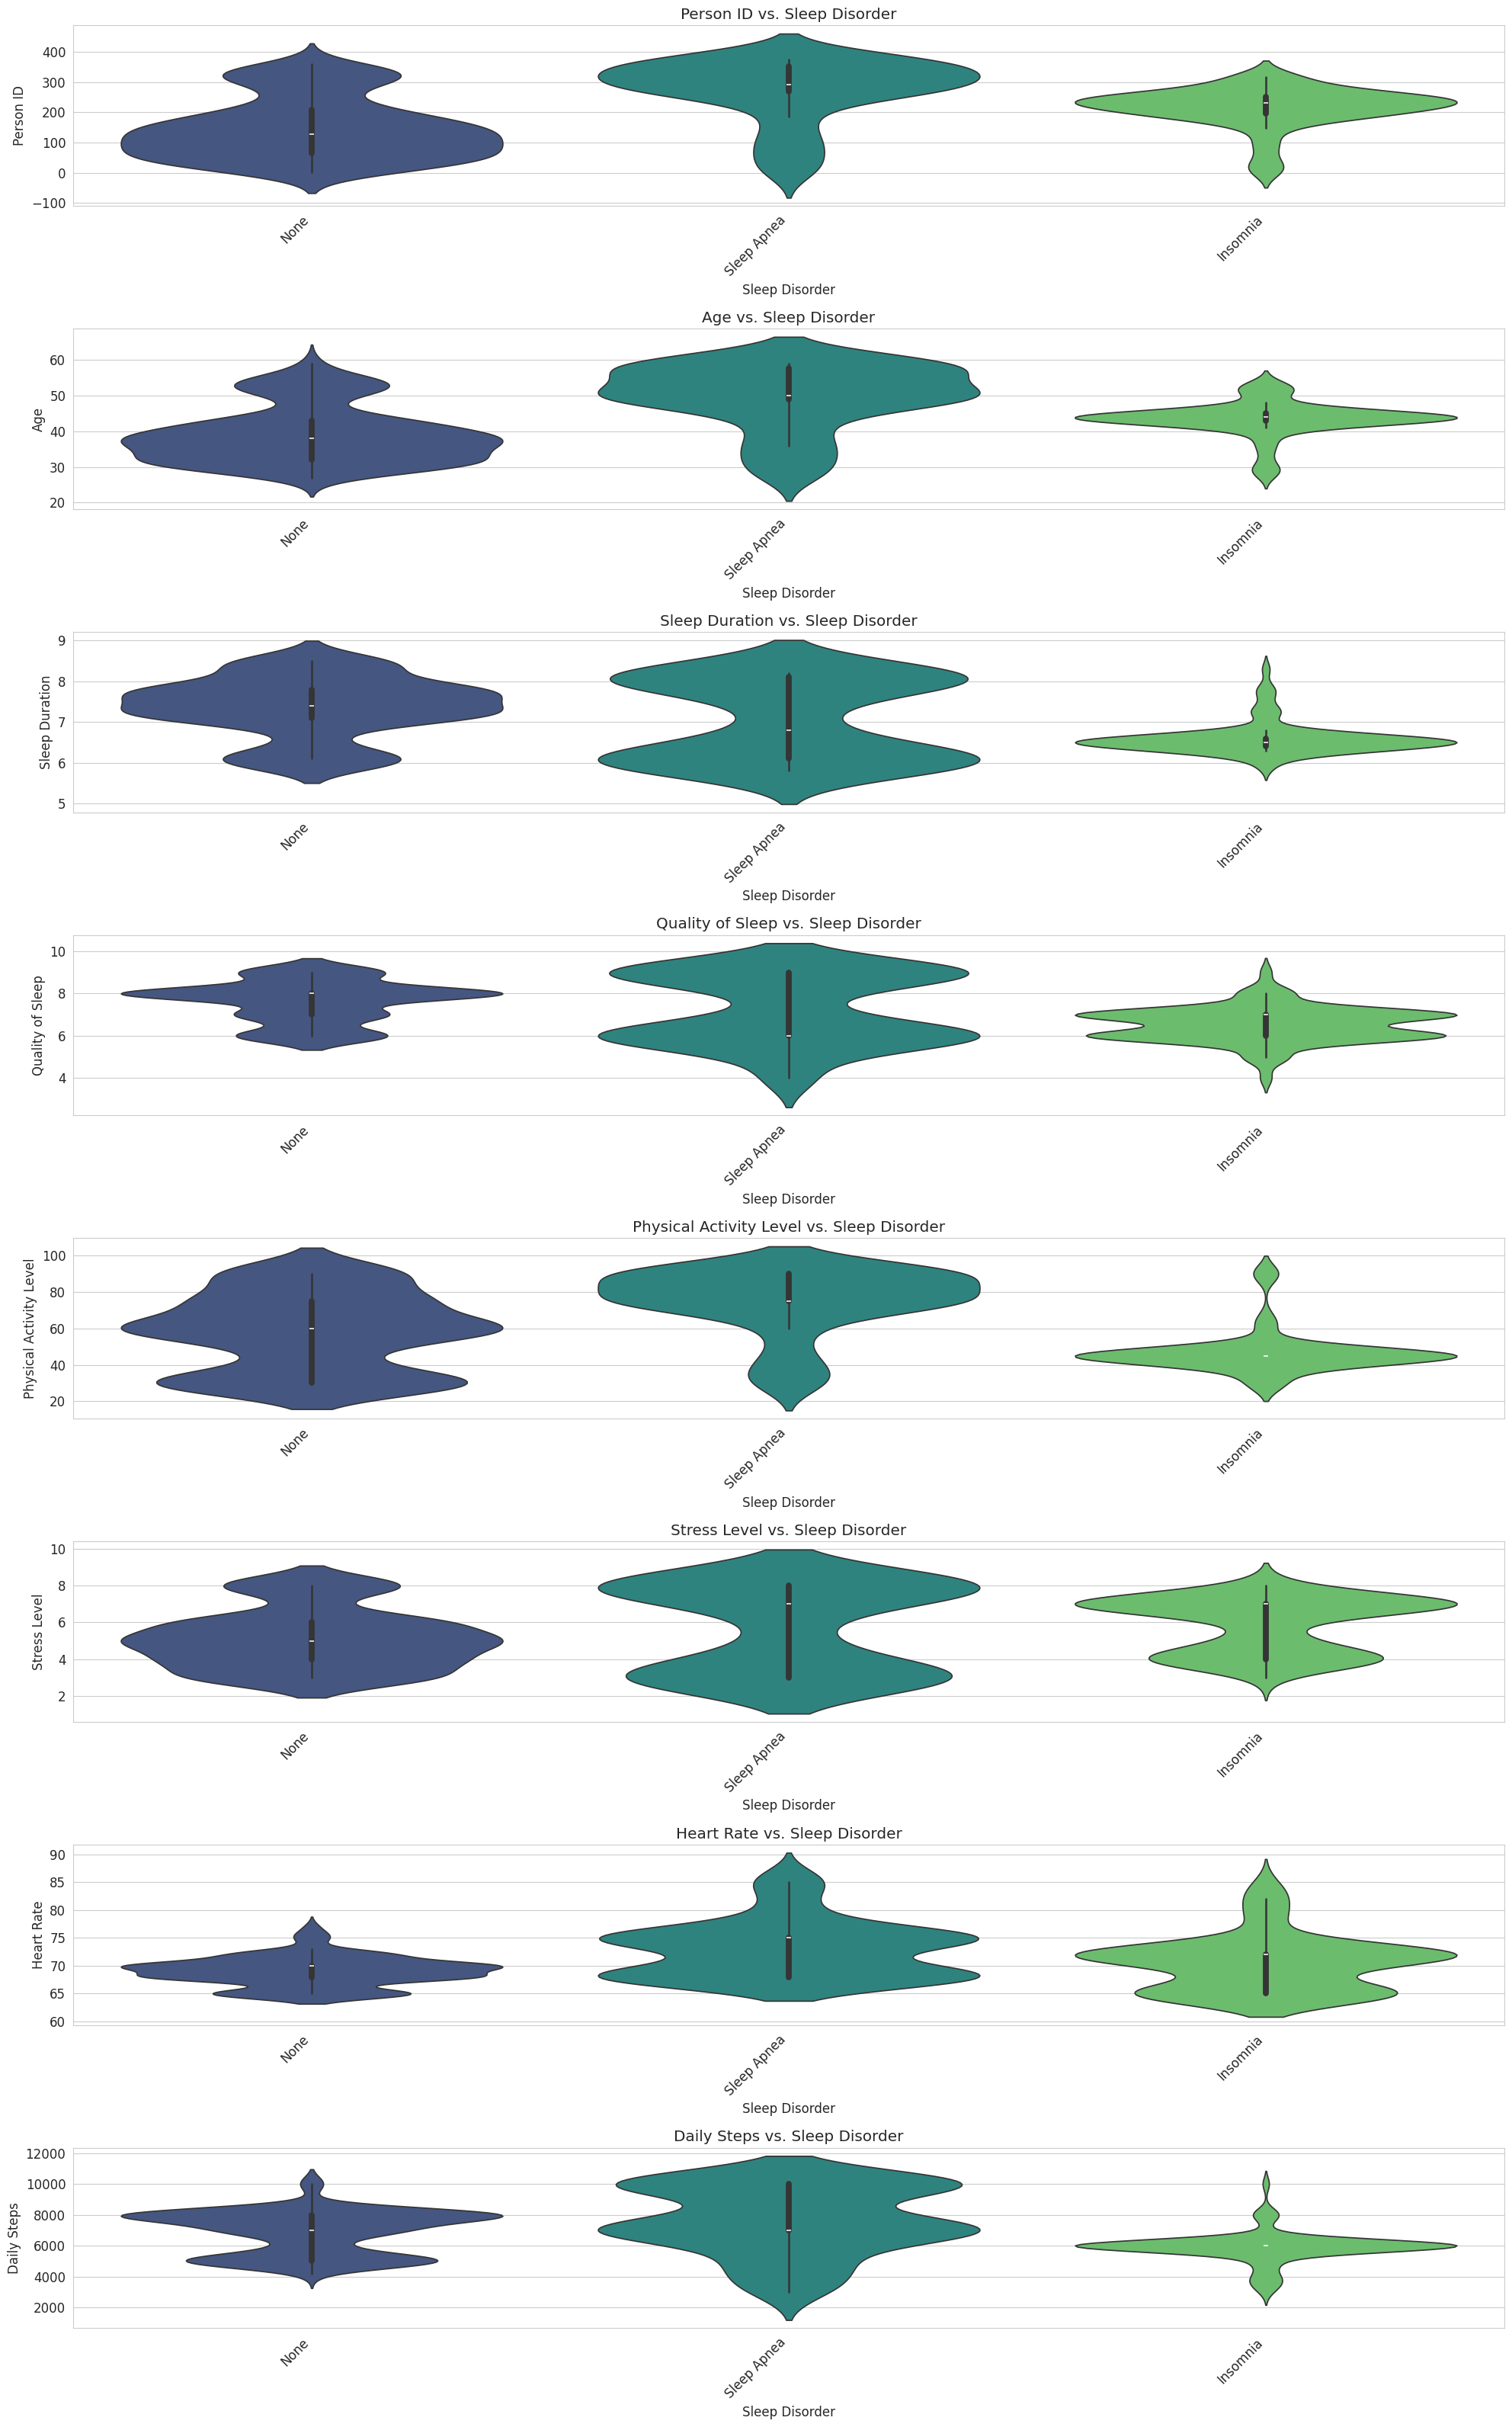

In [ ]:
print("Bivariate Analysis: Numerical Features vs. Sleep Disorder")

# Buat kolom sementara untuk Sleep Disorder dengan mengisi NaN dengan 'None'
df_temp = df.copy()
df_temp['Sleep Disorder_filled'] = df_temp['Sleep Disorder'].fillna('None')

plt.figure(figsize=(20, len(numerical_features) * 4))
for i, feature in enumerate(numerical_features):
    plt.subplot(len(numerical_features), 1, i + 1)
    sns.violinplot(x='Sleep Disorder_filled', y=feature, data=df_temp, palette='viridis')
    plt.title(f'{feature} vs. Sleep Disorder')
    plt.xlabel('Sleep Disorder')
    plt.ylabel(feature)
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Categorical Features


Bivariate Analysis: Categorical Features vs. Sleep Disorder (Stacked Bar Charts)


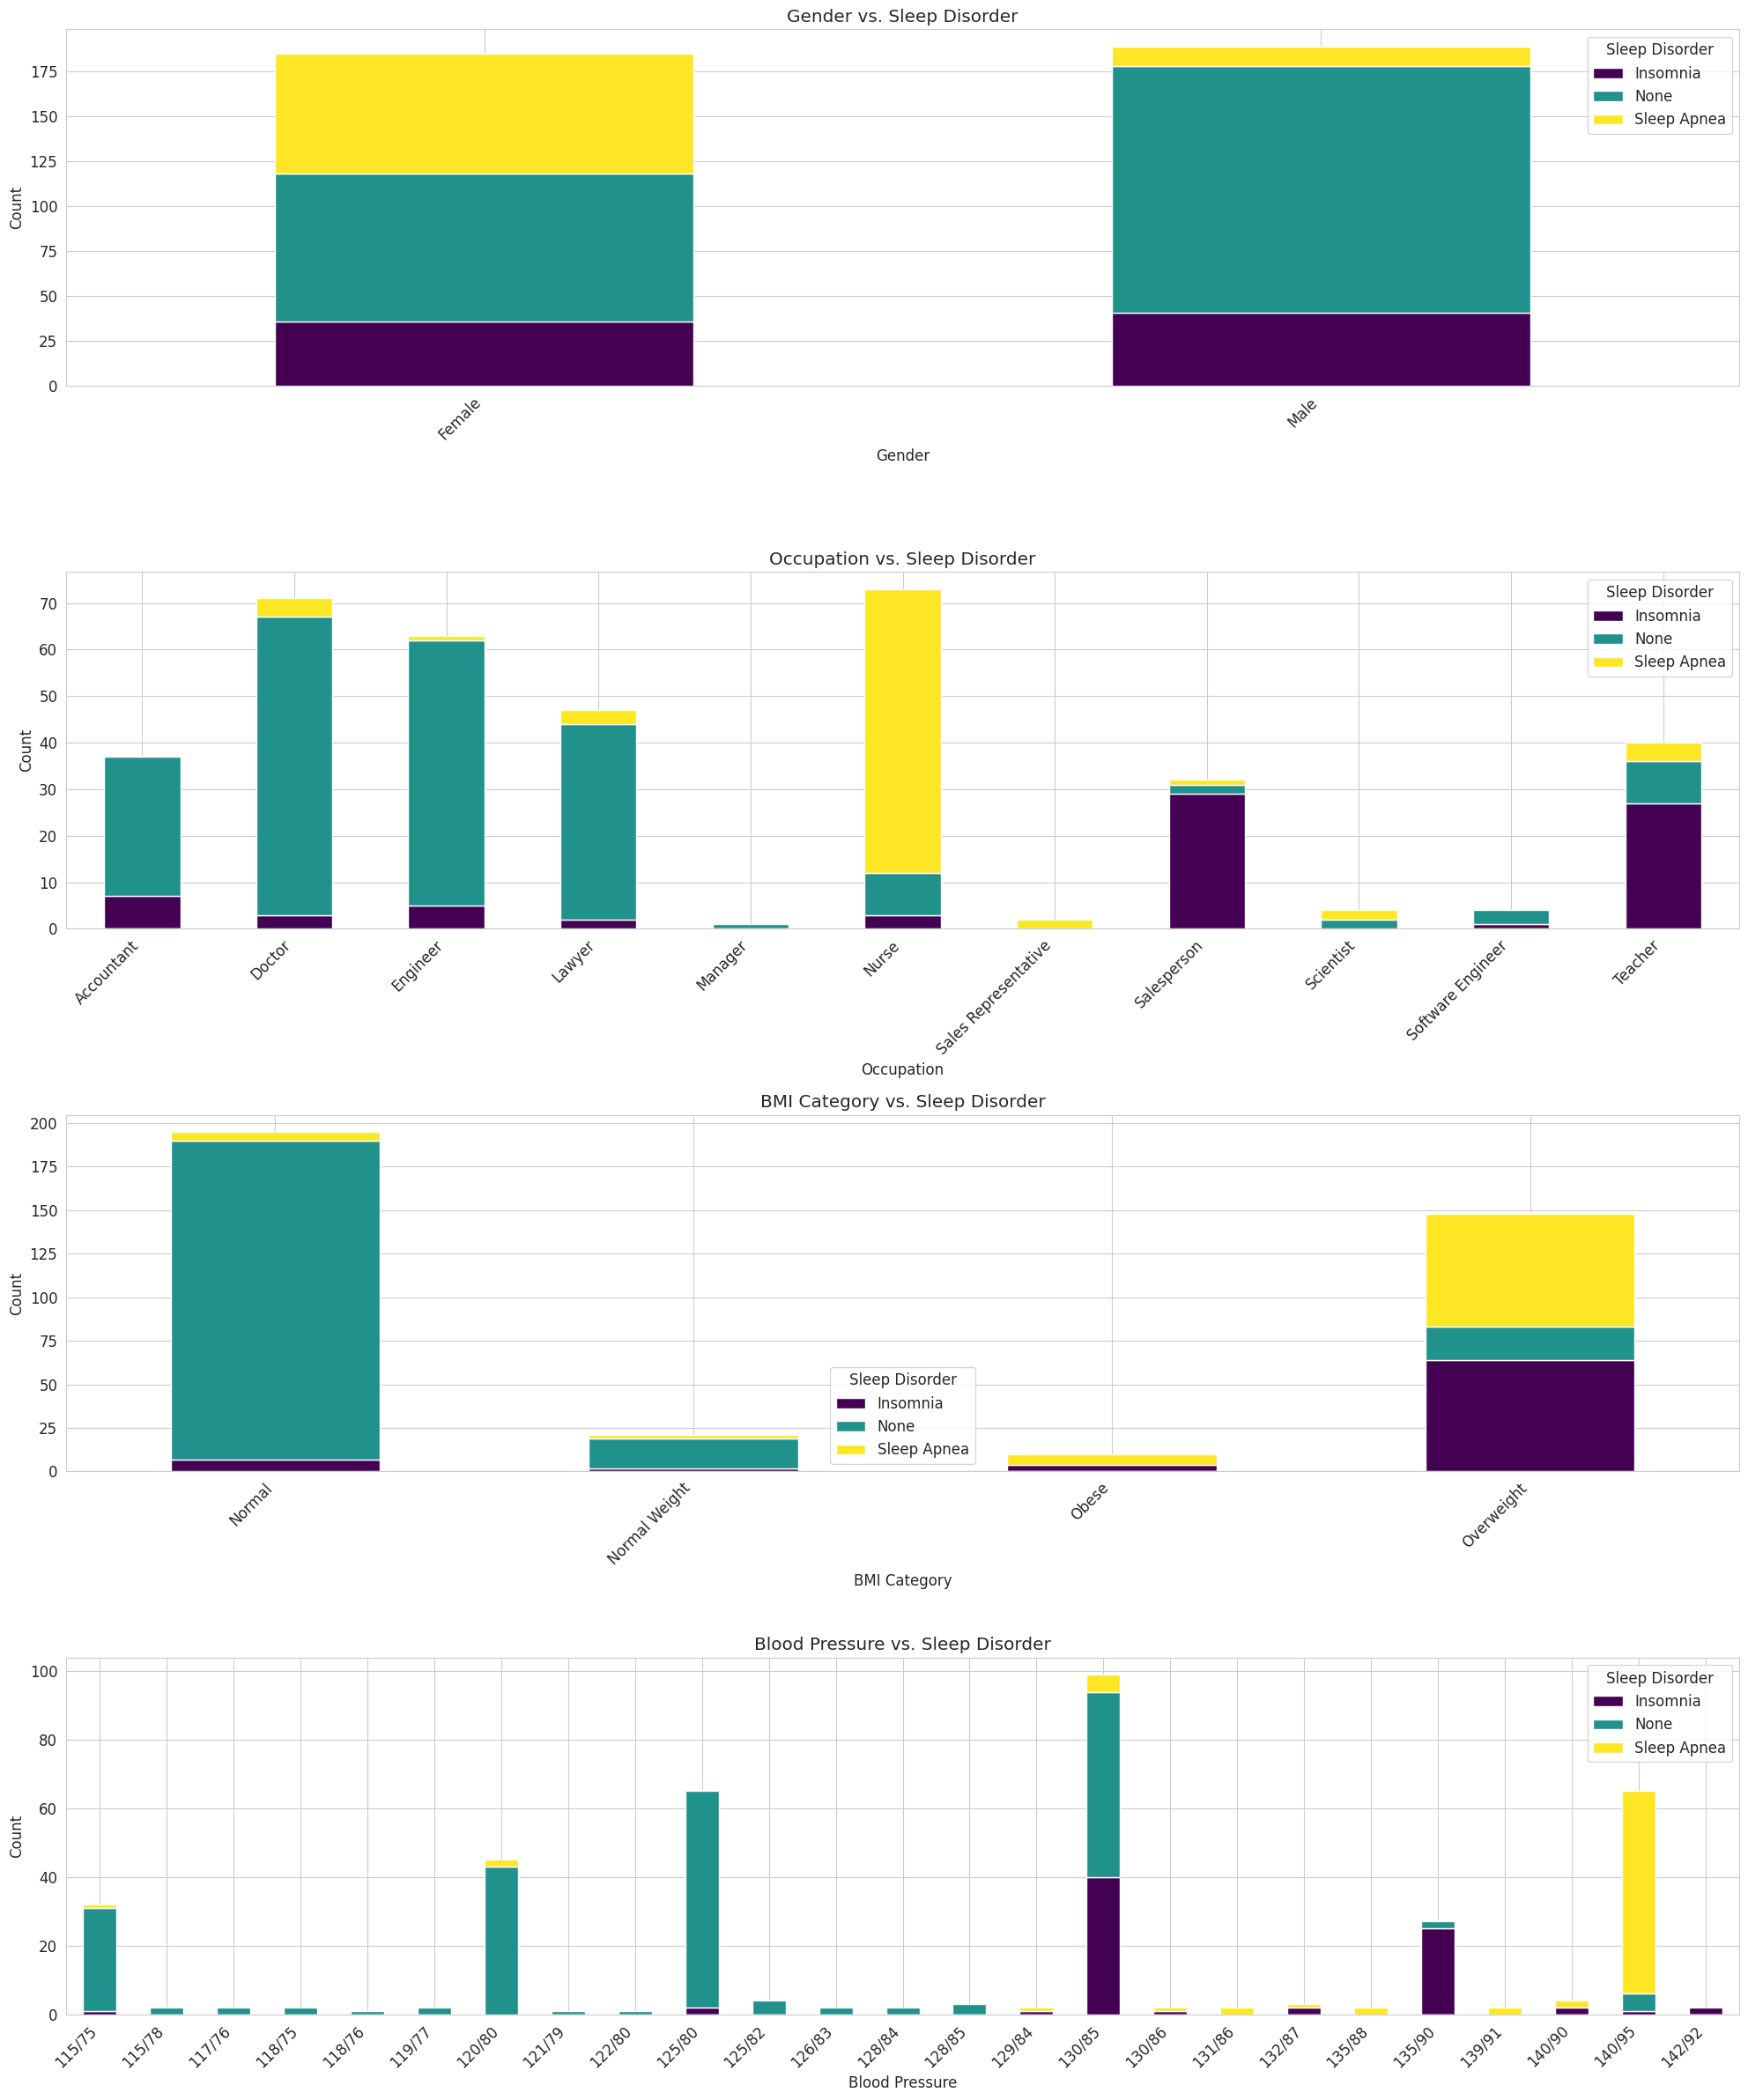

In [ ]:
print("\nBivariate Analysis: Categorical Features vs. Sleep Disorder (Stacked Bar Charts)")
plt.figure(figsize=(20, len(categorical_cols) * 6))
for i, feature in enumerate(categorical_cols):
    plt.subplot(len(categorical_cols), 1, i + 1)
    # Hitung jumlah untuk setiap kategori dan setiap jenis Sleep Disorder
    counts = df_temp.groupby([feature, 'Sleep Disorder_filled']).size().unstack(fill_value=0)
    counts.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='viridis')
    plt.title(f'{feature} vs. Sleep Disorder')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Sleep Disorder')
plt.tight_layout()
plt.show()

## **Multivariate Analysis**

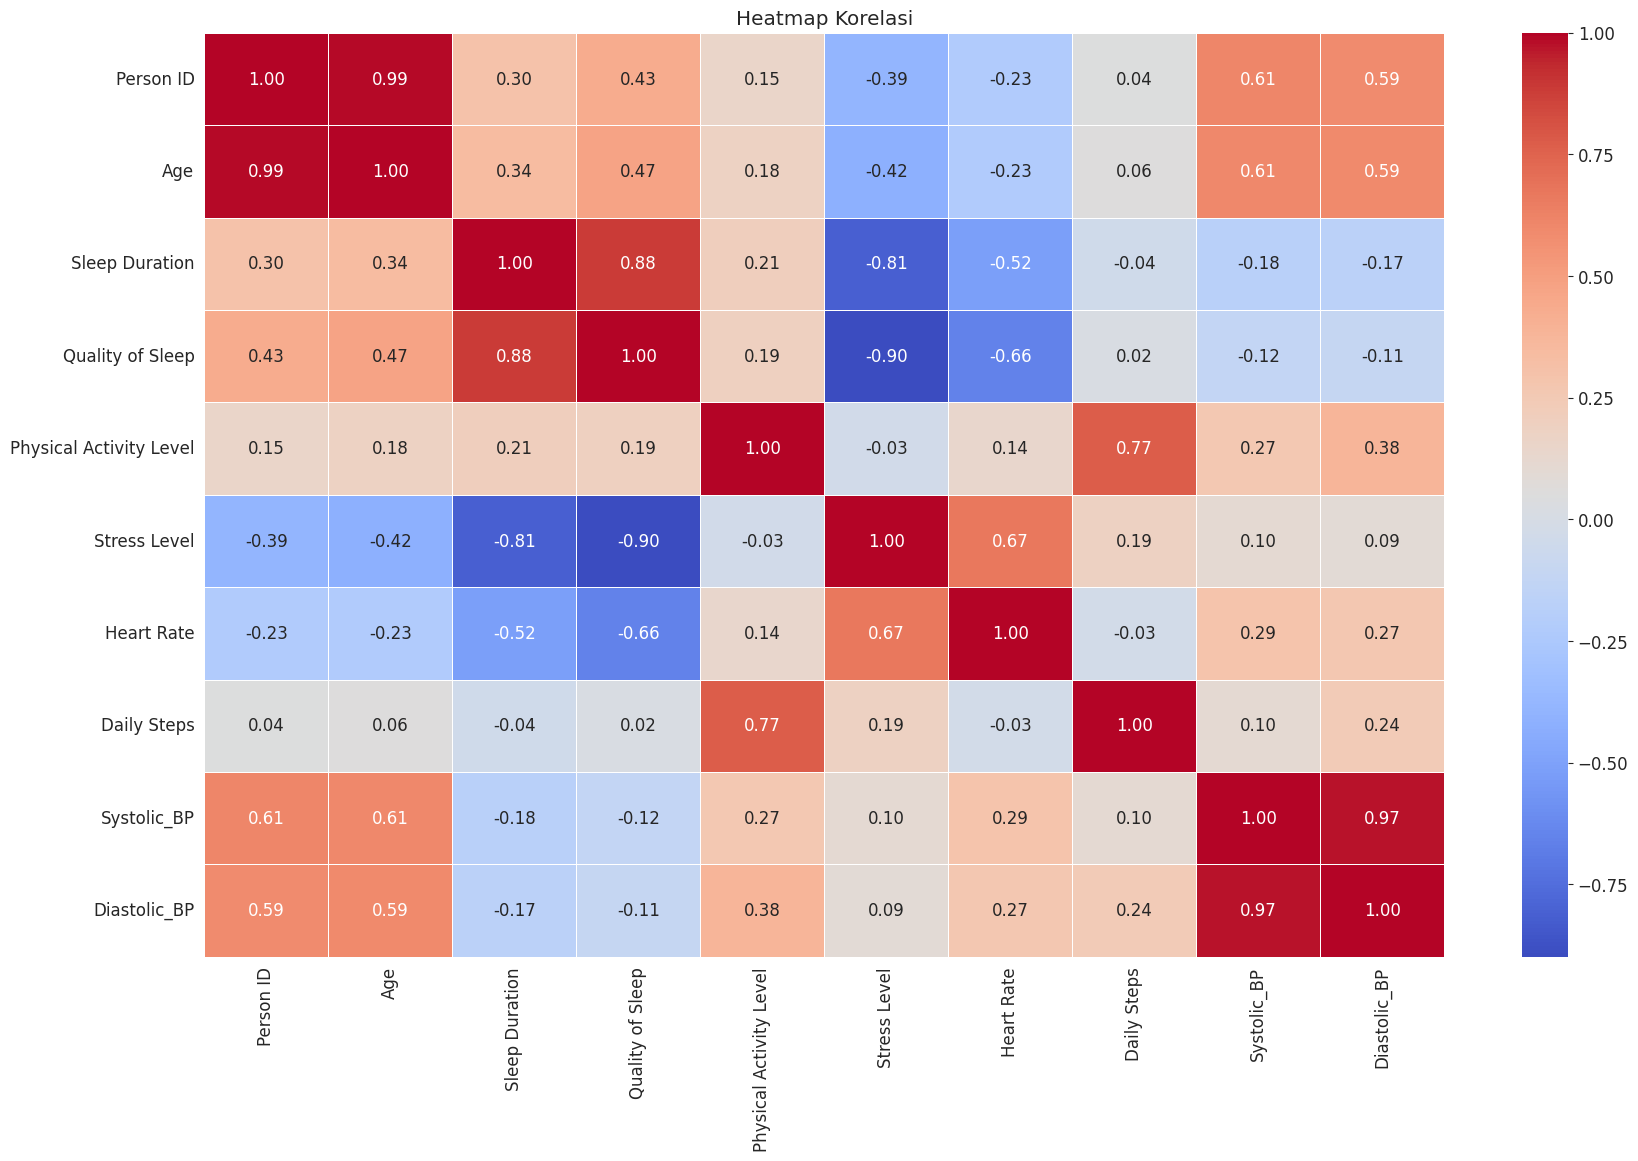

In [ ]:
plt.figure(figsize=(20, 12))
correlation_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

## Drop Features

In [9]:
# Menghapus kolom yang tidak diperlukan
df_clean = df.copy()
kolom_hapus = ['Person ID']
df_clean = df.drop(columns=kolom_hapus)

# Testing
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    object 
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Blood Pressure           374 non-null    object 
 9   Heart Rate               374 non-null    int64  
 10  Daily Steps              374 non-null    int64  
 11  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(6), object(5)
memory usage: 35.2+ KB


## Handling Missing Values

In [10]:
# Menangani Missing Values pada kolom 'Sleep Disorder'
# Mengisi nilai NaN dengan 'None', karena ini adalah fitur kategorikal dan 'None' mewakili tidak ada gangguan tidur.
df_clean['Sleep Disorder'] = df_clean['Sleep Disorder'].fillna('None')

# Memverifikasi tidak ada lagi missing values di kolom 'Sleep Disorder'
print("Jumlah missing values setelah penanganan:")
print(df_clean['Sleep Disorder'].isna().sum())

# Menampilkan value counts untuk memastikan 'None' sudah masuk
print("\nDistribusi kolom 'Sleep Disorder' setelah penanganan:")
print(df_clean['Sleep Disorder'].value_counts())


Jumlah missing values setelah penanganan:
0

Distribusi kolom 'Sleep Disorder' setelah penanganan:
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


## "Blood Pressure" Column Transformation

In [11]:
# Memisahkan kolom 'Blood Pressure' menjadi 'Systolic_BP' dan 'Diastolic_BP'
df_clean[['Systolic_BP', 'Diastolic_BP']] = df_clean['Blood Pressure'].str.split('/', expand=True)

# Mengubah tipe data kolom baru menjadi integer
df_clean['Systolic_BP'] = df_clean['Systolic_BP'].astype(int)
df_clean['Diastolic_BP'] = df_clean['Diastolic_BP'].astype(int)

# Menghapus kolom 'Blood Pressure' yang asli karena sudah dipecah
df_clean.drop(columns=['Blood Pressure'], inplace=True)

# Menampilkan 5 baris pertama DataFrame setelah transformasi
print("DataFrame setelah kolom 'Blood Pressure' dipecah:")
display(df_clean.head())

# Menampilkan informasi DataFrame untuk memverifikasi tipe data baru
print("\nInformasi DataFrame setelah transformasi:")
df_clean.info()

DataFrame setelah kolom 'Blood Pressure' dipecah:


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90



Informasi DataFrame setelah transformasi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    object 
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           374 non-null    object 
 11  Systolic_BP              374 non-null    int64  
 12  Diastolic_BP             374 non-null    int64  
dtypes: float64(1), int64(8), object(4)
me

## Consolidating 'BMI Category' Labels

In [12]:
# Menggabungkan 'Normal Weight' menjadi 'Normal' di kolom 'BMI Category'
df_clean['BMI Category'] = df_clean['BMI Category'].replace('Normal Weight', 'Normal')

# Menampilkan distribusi BMI Category setelah perubahan
print("Distribusi 'BMI Category' setelah penggabungan:")
print(df_clean['BMI Category'].value_counts())

Distribusi 'BMI Category' setelah penggabungan:
BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64


## Data Splitting

In [13]:
# Definisikan fitur (X) dan target (y)
X = df_clean.drop('Sleep Disorder', axis=1)
y = df_clean['Sleep Disorder']

# Lakukan train-test split dengan stratifikasi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")
print(f"Ukuran y_train: {y_train.shape}")
print(f"Ukuran y_test: {y_test.shape}")

print("\nDistribusi Sleep Disorder di y_train:")
print(y_train.value_counts(normalize=True))

print("\nDistribusi Sleep Disorder di y_test:")
print(y_test.value_counts(normalize=True))

Ukuran X_train: (299, 12)
Ukuran X_test: (75, 12)
Ukuran y_train: (299,)
Ukuran y_test: (75,)

Distribusi Sleep Disorder di y_train:
Sleep Disorder
None           0.585284
Sleep Apnea    0.207358
Insomnia       0.207358
Name: proportion, dtype: float64

Distribusi Sleep Disorder di y_test:
Sleep Disorder
None           0.586667
Sleep Apnea    0.213333
Insomnia       0.200000
Name: proportion, dtype: float64


## Data Standardization

In [14]:
# Identifikasi kolom numerik
numerical_cols = X_train.select_dtypes(include=np.number).columns

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Terapkan standardisasi pada data latih
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# Terapkan standardisasi pada data uji (gunakan scaler yang sudah di-fit dari data latih)
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Data numerik pada X_train dan X_test berhasil distandardisasi.")

# Tampilkan beberapa baris pertama setelah standardisasi
print("\nContoh X_train setelah standardisasi:")
display(X_train.head())
print("\nContoh X_test setelah standardisasi:")
display(X_test.head())

Data numerik pada X_train dan X_test berhasil distandardisasi.

Contoh X_train setelah standardisasi:


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP
212,Male,0.086247,Engineer,0.836167,0.577860,1.463474,-0.221292,Normal,-0.003372,0.698923,0.187458,0.055245
366,Female,1.953241,Nurse,1.216127,1.424821,0.740920,-1.362090,Overweight,-0.507502,0.078994,1.484911,1.674667
327,Female,1.253118,Engineer,1.722740,1.424821,-1.426742,-1.362090,Normal,-1.263696,-1.160863,-0.461268,-0.754467
251,Female,0.319621,Teacher,-0.430367,-0.269101,-1.426742,0.349107,Overweight,-1.263696,-0.540934,0.836185,0.864956
314,Female,1.136431,Engineer,1.596087,1.424821,-1.426742,-1.362090,Normal,-1.263696,-1.160863,-0.461268,-0.754467



Contoh X_test setelah standardisasi:


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP
243,Female,0.202934,Teacher,-0.810328,-0.269101,-0.704188,-0.791691,Overweight,-1.263696,-0.540934,0.836185,0.864956
254,Female,0.319621,Teacher,-0.810328,-0.269101,-0.704188,-0.791691,Overweight,-1.263696,-0.540934,0.836185,0.864956
290,Female,0.903057,Nurse,-1.443595,-1.116062,1.463474,1.489905,Overweight,1.256952,1.938780,1.484911,1.674667
371,Female,1.953241,Nurse,1.216127,1.424821,0.740920,-1.362090,Overweight,-0.507502,0.078994,1.484911,1.674667
244,Male,0.202934,Salesperson,-1.063634,-1.116062,-0.704188,0.919506,Overweight,0.500757,-0.540934,0.187458,0.055245


## Endcoding

In [15]:
# Identifikasi kolom kategorikal untuk encoding
ordinal_cols = ['BMI Category']
onehot_cols = ['Gender', 'Occupation']

# Kolom numerik yang sudah distandardisasi akan di-pass through
numerical_cols_passthrough = X_train.select_dtypes(include=np.number).columns.tolist()

# Definisikan urutan kategori untuk OrdinalEncoder pada 'BMI Category'
bmi_category_order = ['Normal', 'Overweight', 'Obese']

# Buat ColumnTransformer untuk menerapkan encoding yang berbeda pada kolom yang berbeda
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols),
        ('ord', OrdinalEncoder(categories=[bmi_category_order]), ordinal_cols)
    ],
    remainder='passthrough' # Kolom numerik yang sudah distandardisasi akan diteruskan
)

# Terapkan transformasi pada data latih dan data uji
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# Dapatkan nama fitur setelah transformasi untuk membuat DataFrame baru
onehot_feature_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(onehot_cols)
ordinal_feature_names = preprocessor.named_transformers_['ord'].get_feature_names_out(ordinal_cols)

# Gabungkan semua nama fitur dalam urutan yang benar
all_feature_names = list(onehot_feature_names) + list(ordinal_feature_names) + numerical_cols_passthrough

# Konversi hasil transformasi kembali ke DataFrame
X_train = pd.DataFrame(X_train_encoded, columns=all_feature_names, index=X_train.index)
X_test = pd.DataFrame(X_test_encoded, columns=all_feature_names, index=X_test.index)

print("Fitur kategorikal di X_train dan X_test berhasil di-encoding.")

# Tampilkan beberapa baris pertama setelah encoding
print("\nContoh X_train setelah encoding:")
display(X_train.head())
print("\nContoh X_test setelah encoding:")
display(X_test.head())

Fitur kategorikal di X_train dan X_test berhasil di-encoding.

Contoh X_train setelah encoding:


,Gender_Female,Gender_Male,Occupation_Accountant,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,...,BMI Category,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP
212,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.086247,0.836167,0.577860,1.463474,-0.221292,-0.003372,0.698923,0.187458,0.055245
366,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.953241,1.216127,1.424821,0.740920,-1.362090,-0.507502,0.078994,1.484911,1.674667
327,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.253118,1.722740,1.424821,-1.426742,-1.362090,-1.263696,-1.160863,-0.461268,-0.754467
251,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.319621,-0.430367,-0.269101,-1.426742,0.349107,-1.263696,-0.540934,0.836185,0.864956
314,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.136431,1.596087,1.424821,-1.426742,-1.362090,-1.263696,-1.160863,-0.461268,-0.754467



Contoh X_test setelah encoding:


,Gender_Female,Gender_Male,Occupation_Accountant,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,...,BMI Category,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP
243,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.202934,-0.810328,-0.269101,-0.704188,-0.791691,-1.263696,-0.540934,0.836185,0.864956
254,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.319621,-0.810328,-0.269101,-0.704188,-0.791691,-1.263696,-0.540934,0.836185,0.864956
290,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.903057,-1.443595,-1.116062,1.463474,1.489905,1.256952,1.938780,1.484911,1.674667
371,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.953241,1.216127,1.424821,0.740920,-1.362090,-0.507502,0.078994,1.484911,1.674667
244,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.202934,-1.063634,-1.116062,-0.704188,0.919506,0.500757,-0.540934,0.187458,0.055245
